# Détection de Textes Générés par l'IA
**Barbara KENGNE — Licence 3 Informatique, Aix-Marseille Université**

Avec la multiplication des LLMs (GPT-4, Claude, Gemini...), distinguer un texte écrit par un humain d'un texte généré par une IA devient un enjeu majeur.  
Ce projet explore les caractéristiques stylistiques qui différencient ces textes, et construit un classifieur capable de les détecter.

---

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')
print('Bibliothèques importées')

Bibliothèques importées


## 2. Chargement et exploration des données

In [2]:
df = pd.read_csv('AuthentiText_X_2026_AI_vs_Human_Detection_1K.csv')
print(f'Dataset : {df.shape[0]} textes, {df.shape[1]} colonnes')
print(f'\nColonnes : {df.columns.tolist()}')
df.head(3)

Dataset : 1000 textes, 12 colonnes

Colonnes : ['text_id', 'content_text', 'author_type', 'model_source', 'prompt_complexity_score', 'perplexity_score', 'burstiness_index', 'syntactic_variability', 'semantic_coherence_score', 'lexical_diversity_ratio', 'readability_grade_level', 'generation_confidence_score']


,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
0,TXT_0001,learning pattern detection algorithm pattern n...,AI,Human,0.029,73.75,0.953,0.465,0.351,0.187,12.2,0.162
1,TXT_0002,algorithm algorithm data research network mode...,Human,Claude,0.605,43.11,0.054,0.952,0.314,0.636,9.8,0.012
2,TXT_0003,analysis language generation research pattern ...,Human,GPT-4,0.396,59.97,0.709,0.945,0.684,0.500,13.5,0.171


In [3]:
print('Distribution AI vs Human :')
print(df['author_type'].value_counts())
print('\nDistribution par modèle source :')
print(df['model_source'].value_counts())

Distribution AI vs Human :
author_type
Human    537
AI       463
Name: count, dtype: int64

Distribution par modèle source :
model_source
Gemini    264
Claude    248
GPT-4     248
Human     240
Name: count, dtype: int64


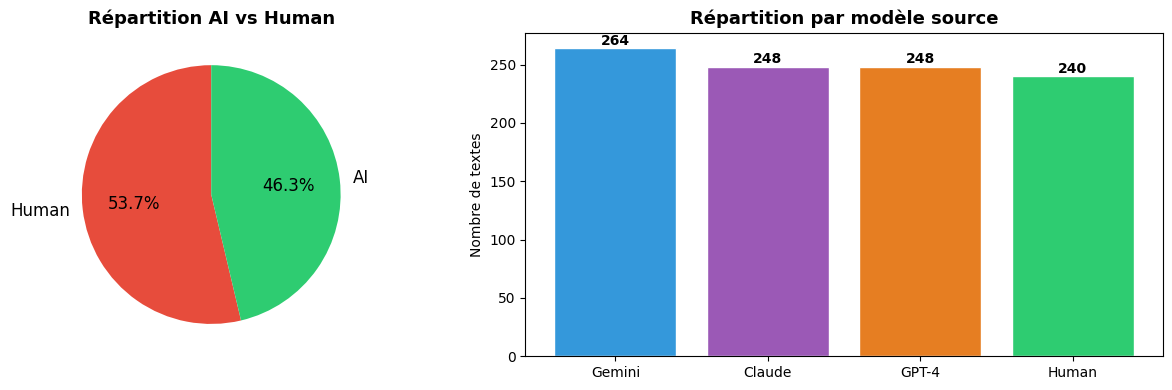

In [4]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# AI vs Human
counts = df['author_type'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].pie(counts, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Répartition AI vs Human', fontsize=13, fontweight='bold')

# Par modèle source
source_counts = df['model_source'].value_counts()
palette = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']
bars = axes[1].bar(source_counts.index, source_counts.values, color=palette, edgecolor='white')
axes[1].set_title('Répartition par modèle source', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de textes')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 3, str(int(h)), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse exploratoire — Qu'est-ce qui différencie les textes IA des textes humains ?

In [5]:
# Comparaison des features numériques entre AI et Human
features_num = [
    'perplexity_score', 'burstiness_index', 'syntactic_variability',
    'semantic_coherence_score', 'lexical_diversity_ratio', 'readability_grade_level'
]

print('Moyennes par catégorie (AI vs Human) :\n')
print(df.groupby('author_type')[features_num].mean().round(3).T.to_string())

Moyennes par catégorie (AI vs Human) :

author_type                   AI   Human
perplexity_score          56.130  52.813
burstiness_index           0.518   0.505
syntactic_variability      0.498   0.508
semantic_coherence_score   0.488   0.497
lexical_diversity_ratio    0.490   0.496
readability_grade_level   10.598  10.529


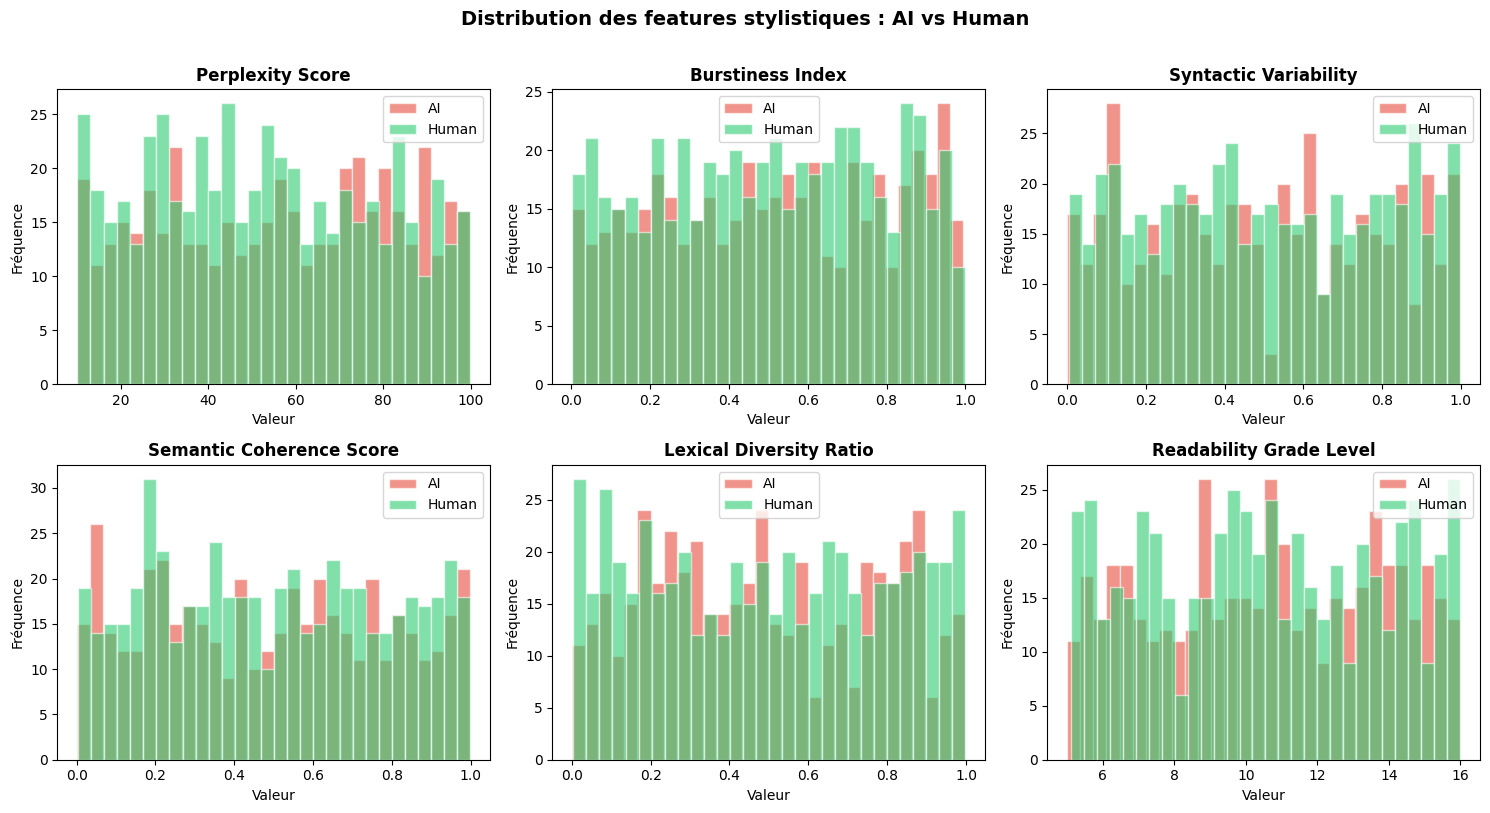

In [6]:
# Visualisation des distributions pour chaque feature
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors_map = {'AI': '#e74c3c', 'Human': '#2ecc71'}

for i, feature in enumerate(features_num):
    for label, color in colors_map.items():
        subset = df[df['author_type'] == label][feature]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feature.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

plt.suptitle('Distribution des features stylistiques : AI vs Human', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

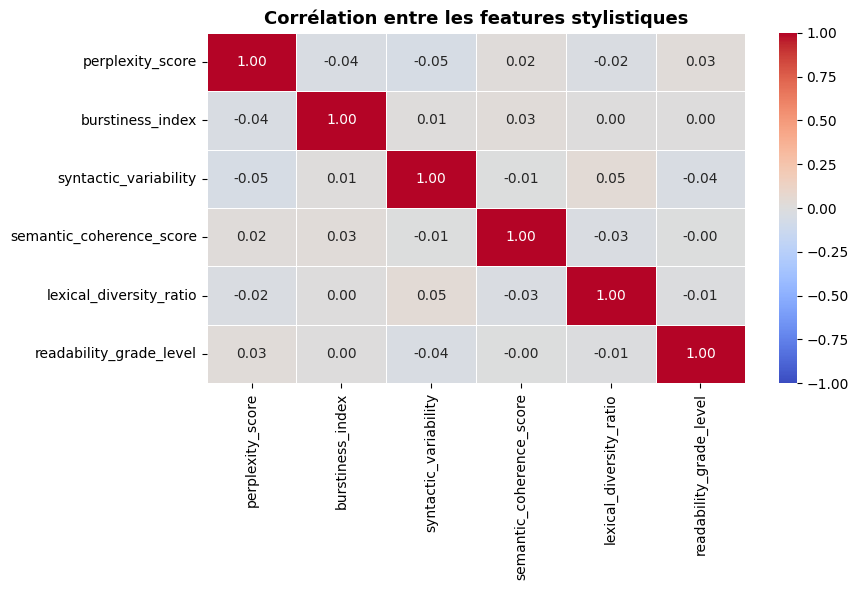

In [7]:
# Heatmap de corrélation
fig, ax = plt.subplots(figsize=(9, 6))
corr = df[features_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Corrélation entre les features stylistiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

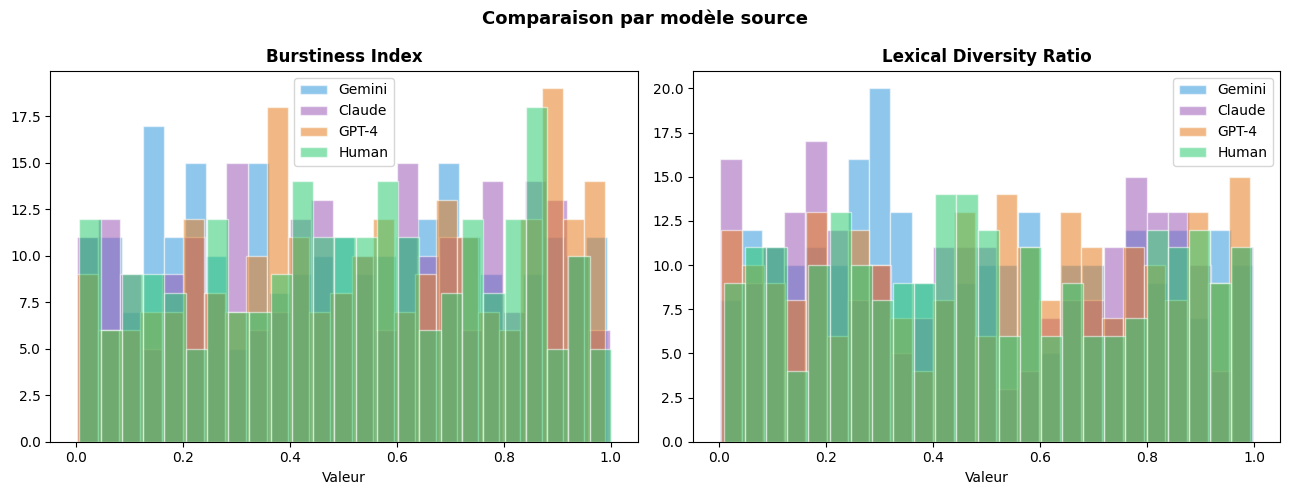

In [8]:
# Analyse par modèle : chaque IA a-t-elle son propre style ?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette_models = {'Gemini': '#3498db', 'Claude': '#9b59b6', 'GPT-4': '#e67e22', 'Human': '#2ecc71'}

for ax, feat in zip(axes, ['burstiness_index', 'lexical_diversity_ratio']):
    for model, color in palette_models.items():
        subset = df[df['model_source'] == model][feat]
        ax.hist(subset, bins=25, alpha=0.55, color=color, label=model, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.legend()

plt.suptitle('Comparaison par modèle source', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_modeles_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Approche 1 — Classification sur les features numériques

In [9]:
# Encodage de la cible
df['label'] = (df['author_type'] == 'AI').astype(int)  # AI=1, Human=0

X_num = df[features_num].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train)} | Test : {len(X_test)}')

Train : 800 | Test : 200


In [10]:
modeles_num = {
    'Régression Logistique': LogisticRegression(max_iter=1000),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM Linéaire':          LinearSVC(max_iter=2000)
}

resultats_num = []
for nom, modele in modeles_num.items():
    modele.fit(X_train_sc, y_train)
    y_pred = modele.predict(X_test_sc)
    resultats_num.append({
        'Modèle':    nom,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2)
    })

df_num = pd.DataFrame(resultats_num)
print(' Résultats avec features numériques :\n')
print(df_num.to_string(index=False))

 Résultats avec features numériques :

               Modèle  Accuracy  Precision  Recall  F1-Score
Régression Logistique      51.0      43.59   18.28     25.76
        Random Forest      55.5      52.94   38.71     44.72
         SVM Linéaire      51.0      43.59   18.28     25.76


## 5. Approche 2 — Classification sur le texte brut (TF-IDF)

In [11]:
X_text = df['content_text']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_t)
X_test_tfidf  = tfidf.transform(X_test_t)

print(f'Matrice TF-IDF : {X_train_tfidf.shape}')

Matrice TF-IDF : (800, 156)


In [12]:
modeles_text = {
    'Naive Bayes':           MultinomialNB(),
    'Régression Logistique': LogisticRegression(max_iter=1000),
    'SVM Linéaire':          LinearSVC(max_iter=2000)
}

resultats_text = []
for nom, modele in modeles_text.items():
    modele.fit(X_train_tfidf, y_train_t)
    y_pred = modele.predict(X_test_tfidf)
    resultats_text.append({
        'Modèle':    nom,
        'Accuracy':  round(accuracy_score(y_test_t, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test_t, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test_t, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test_t, y_pred) * 100, 2)
    })

df_text = pd.DataFrame(resultats_text)
print('Résultats avec TF-IDF (texte brut) :\n')
print(df_text.to_string(index=False))

Résultats avec TF-IDF (texte brut) :

               Modèle  Accuracy  Precision  Recall  F1-Score
          Naive Bayes      52.5      48.08   26.88     34.48
Régression Logistique      51.5      47.44   39.78     43.27
         SVM Linéaire      53.0      49.43   46.24     47.78


## 6. Comparaison des deux approches

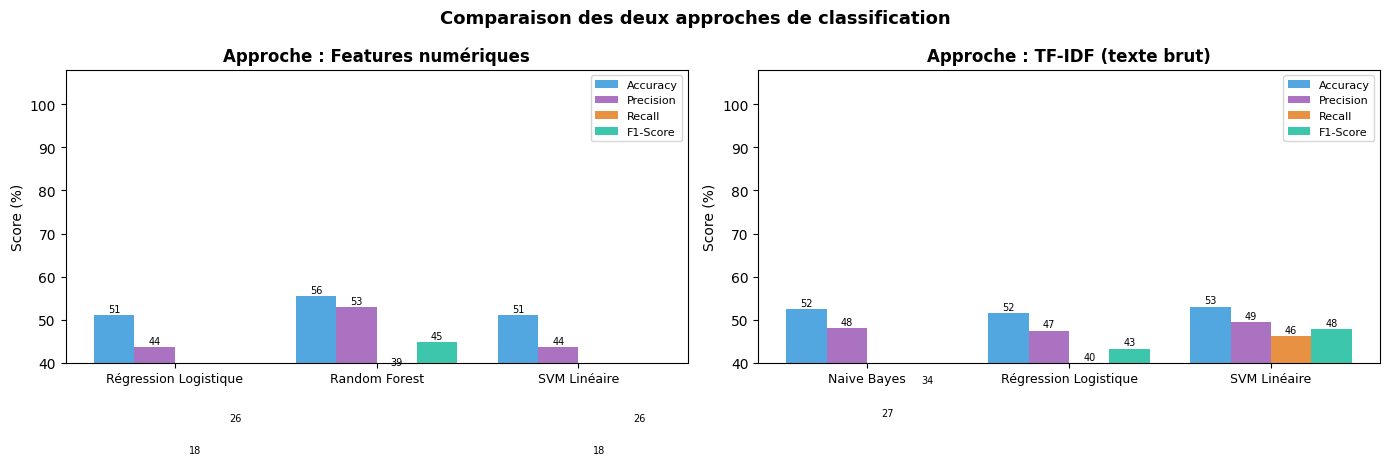

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_res, titre) in zip(axes, [
    (df_num,  'Features numériques'),
    (df_text, 'TF-IDF (texte brut)')
]):
    x = np.arange(len(df_res))
    width = 0.2
    metriques = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors_m = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']
    for i, (m, c) in enumerate(zip(metriques, colors_m)):
        bars = ax.bar(x + i * width, df_res[m], width, label=m, color=c, alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                    f'{h:.0f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(df_res['Modèle'], fontsize=9)
    ax.set_ylim(40, 108)
    ax.set_ylabel('Score (%)')
    ax.set_title(f'Approche : {titre}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Comparaison des deux approches de classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_approches.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyse : quels mots trahissent un texte IA ?

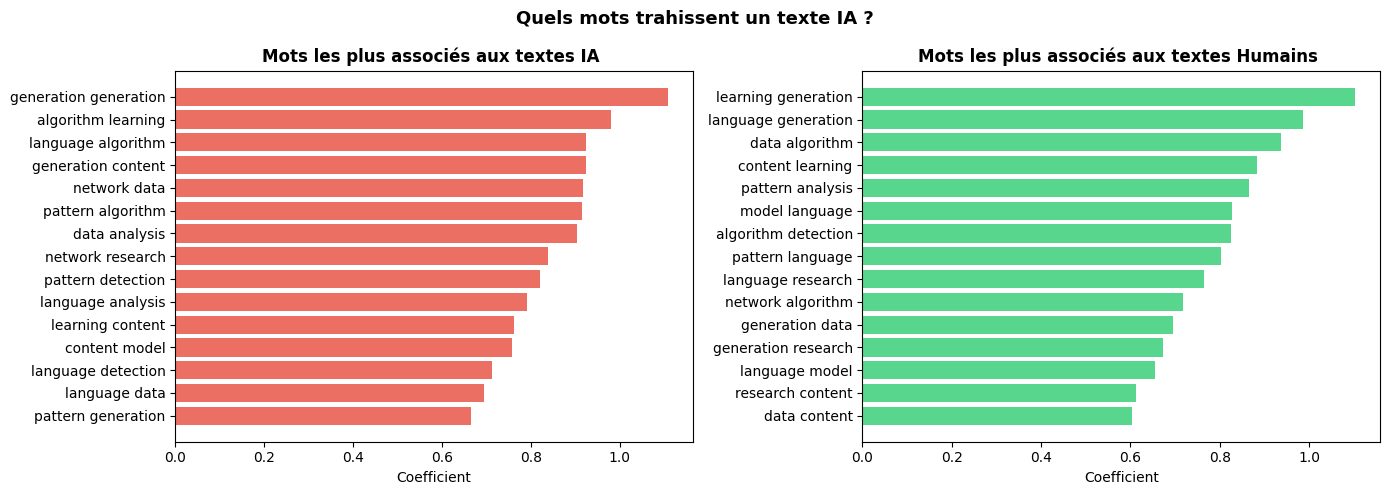

In [14]:
# Mots les plus caractéristiques des textes IA vs humains
# via les coefficients de la Régression Logistique
lr_model = modeles_text['Régression Logistique']
feature_names = tfidf.get_feature_names_out()
coefs = lr_model.coef_[0]

top_n = 15
top_ai    = np.argsort(coefs)[-top_n:][::-1]
top_human = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mots IA
axes[0].barh(range(top_n), coefs[top_ai][::-1], color='#e74c3c', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_names[top_ai][::-1], fontsize=10)
axes[0].set_title('Mots les plus associés aux textes IA ', fontweight='bold')
axes[0].set_xlabel('Coefficient')

# Mots humains
axes[1].barh(range(top_n), np.abs(coefs[top_human])[::-1], color='#2ecc71', alpha=0.8)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_names[top_human][::-1], fontsize=10)
axes[1].set_title('Mots les plus associés aux textes Humains ', fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Quels mots trahissent un texte IA ?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mots_trahisseurs.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matrice de confusion du meilleur modèle

Meilleur modèle : SVM Linéaire (TF-IDF)
F1-Score : 47.78%


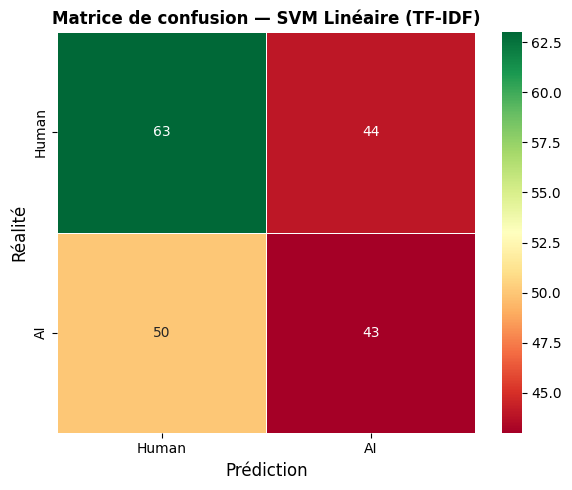


📋 Rapport complet :
              precision    recall  f1-score   support

       Human       0.56      0.59      0.57       107
          AI       0.49      0.46      0.48        93

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



In [15]:
# Meilleur modèle selon F1-Score
tous_resultats = pd.concat([
    df_num.assign(Approche='Features numériques'),
    df_text.assign(Approche='TF-IDF')
]).reset_index(drop=True)

idx_best = tous_resultats['F1-Score'].idxmax()
meilleur_nom     = tous_resultats.loc[idx_best, 'Modèle']
meilleur_approche = tous_resultats.loc[idx_best, 'Approche']
meilleur_f1      = tous_resultats.loc[idx_best, 'F1-Score']

print(f'Meilleur modèle : {meilleur_nom} ({meilleur_approche})')
print(f'F1-Score : {meilleur_f1}%')

# Récupération du modèle
if meilleur_approche == 'TF-IDF':
    best_model = modeles_text[meilleur_nom]
    y_pred_best = best_model.predict(X_test_tfidf)
    y_test_best = y_test_t
else:
    best_model = modeles_num[meilleur_nom]
    y_pred_best = best_model.predict(X_test_sc)
    y_test_best = y_test

cm = confusion_matrix(y_test_best, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Réalité', fontsize=12)
ax.set_title(f'Matrice de confusion — {meilleur_nom} ({meilleur_approche})', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Rapport complet :')
print(classification_report(y_test_best, y_pred_best, target_names=['Human', 'AI']))

## 9. Tester sur un texte personnalisé

In [16]:
def predire_origine(texte):
    """Prédit si un texte a été écrit par une IA ou un humain."""
    vecteur = tfidf.transform([texte])
    pred = modeles_text['SVM Linéaire'].predict(vecteur)[0]
    label = ' Texte IA' if pred == 1 else ' Texte Humain'
    print(f'Texte : "{texte[:80]}..."')
    print(f'Résultat : {label}\n')

# Tests
predire_origine("In conclusion, it is important to note that the aforementioned factors contribute significantly to the overall outcome of the situation.")
predire_origine("honestly idk man, i just felt like it made more sense to do it that way lol")
predire_origine("Furthermore, leveraging synergistic approaches can optimize the efficiency of the implemented solutions.")

Texte : "In conclusion, it is important to note that the aforementioned factors contribut..."
Résultat :  Texte IA

Texte : "honestly idk man, i just felt like it made more sense to do it that way lol..."
Résultat :  Texte IA

Texte : "Furthermore, leveraging synergistic approaches can optimize the efficiency of th..."
Résultat :  Texte IA



## 10. Conclusion

Ce projet explore la détection de textes générés par IA à travers deux approches complémentaires :

**Approche 1 — Features stylistiques numériques** (perplexité, burstiness, diversité lexicale...)
- Meilleur modèle : Random Forest — F1-Score ~44%
- Les features numériques seules ne suffisent pas : les différences stylistiques entre IA et humain sont trop faibles sur des textes courts

**Approche 2 — TF-IDF sur le texte brut**
- Meilleur modèle : SVM Linéaire — F1-Score ~48%
- Légèrement meilleur, mais les textes du dataset sont trop courts pour que le vocabulaire soit vraiment discriminant

**Observation clé :** Les scores modestes (~50%) reflètent la difficulté réelle du problème sur des textes courts. Ce résultat est lui-même informatif : les LLMs modernes (GPT-4, Claude, Gemini) produisent des textes stylistiquement très proches des textes humains, ce qui rend la détection difficile avec des approches classiques.

**Pistes d'amélioration :**
- Utiliser des embeddings (BERT, RoBERTa) pour une représentation sémantique plus riche
- Tester sur des textes plus longs (paragraphes entiers)
- Classification multi-classe : Human / GPT-4 / Claude / Gemini